# OS Analysis

**This notebook analyzes overall survival in patients with advanced head and neck cancer treated with first-line pembrolizumab plus platinum-based chemotherapy or pembrolizumab.** 

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/pembrochemo_pembro_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate
1420,F3C2940489071,pembro,2020-11-11
1454,F683980D8E48B,pembro,2016-09-14
48,FC2C9CCB334F5,pembro_platinum,2019-12-13


In [4]:
treatment_df.shape

(1854, 3)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'pembro_platinum').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [7]:
features_df.shape

(1736, 162)

In [8]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [9]:
df.shape

(1736, 165)

In [10]:
df = df.query('adv_diagnosis_year <= 2021')

In [11]:
df.shape

(1257, 165)

In [12]:
df.PDL1_status.value_counts(normalize = True)

PDL1_status
unknown     0.848846
positive    0.151154
Name: proportion, dtype: float64

## Survival analysis with IPTW

In [13]:
df.treatment.value_counts()

treatment
0    863
1    394
Name: count, dtype: int64

In [14]:
# Percent censoring
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.320973
1    0.365482
Name: event, dtype: float64

In [15]:
estimator = IPTWSurvivalEstimator()

In [16]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['HPVStatus_mod', 'PDL1_status'],
              cont_var = ['days_diagnosis_to_adv', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'percent_change_weight', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'ecog_index_na', 'ses_mod_na', 'medicaid', 'before_2020', 'days_to_treatment_before_30d', 'received_surgery', 'received_radiation', 'had_local_recurrence', 'had_distant_recurrence', 'SmokingStatus'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [17]:
iptw_df = estimator.transform()

In [18]:
ps_fig = estimator.propensity_score_plot(bins = 30)

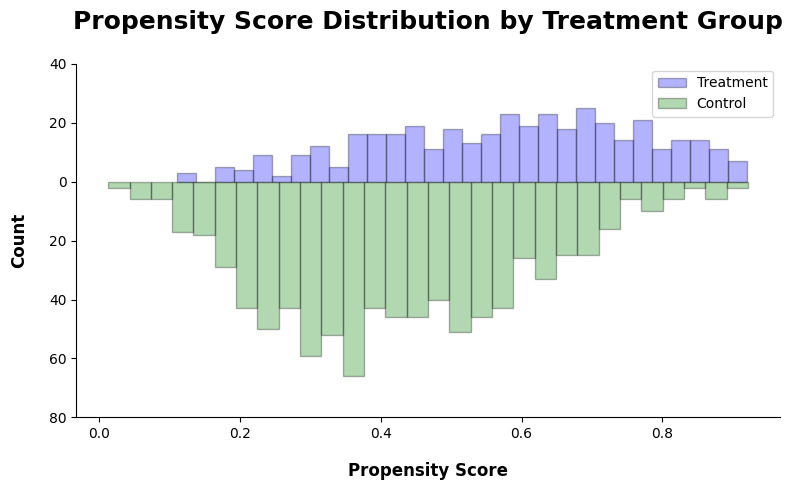

In [19]:
ps_fig

In [20]:
smd_df, smd_fig = estimator.standardized_mean_differences(return_fig = True)

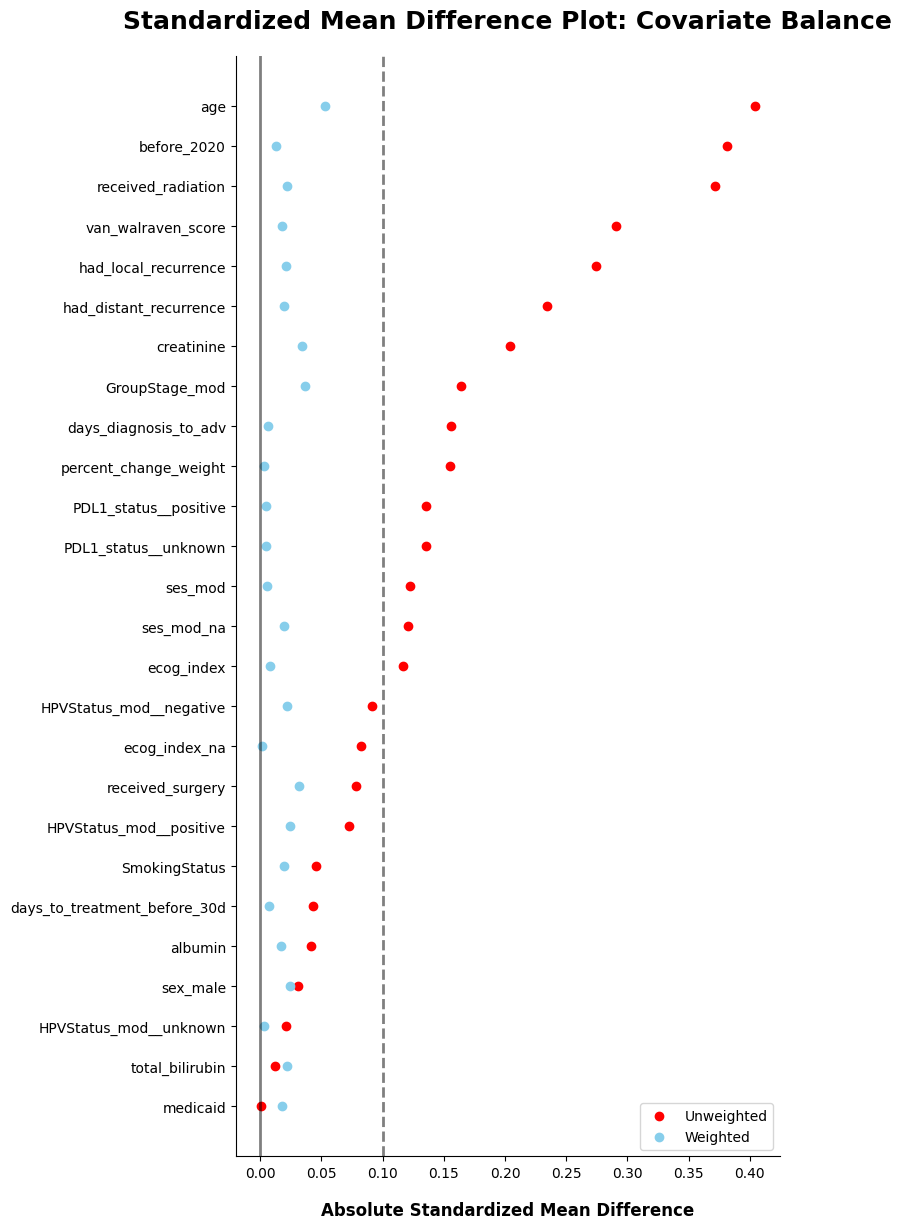

In [21]:
smd_fig

In [22]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42,
                                                               n_jobs = -1)

In [23]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [180, 365, 730, 1095],
                                     rmst_time_points = [180, 365, 730, 1095],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [24]:
# Median results
print('Median survival results')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'Pembrolizumab: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
Pembrolizumab plus chemotherapy: (14.1, 12.0, 17.8) months
Pembrolizumab: (13.7, 11.8, 17.3) months
Difference: (0.4, -3.5, 4.2) months


In [25]:
print('RMST results at 6 months')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][180])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][180])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][180])} days')

print('')
print('RMST results at 1 year')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][365])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][365])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][365])} days')

print('')
print('RMST results at 2 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

print('')
print('RMST results at 3 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][1095])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][1095])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1095])} days')

RMST results at 6 months
Pembrolizumab plus chemotherapy: (157.4, 152.3, 162.2) days
Pembrolizumab: (151.6, 146.9, 155.6) days
Difference: (5.8, -0.9, 12.3) days

RMST results at 1 year
Pembrolizumab plus chemotherapy: (276.0, 263.5, 287.8) days
Pembrolizumab: (264.5, 253.9, 274.3) days
Difference: (11.5, -4.8, 27.6) days

RMST results at 2 years
Pembrolizumab plus chemotherapy: (435.8, 407.0, 465.0) days
Pembrolizumab: (425.5, 403.1, 448.3) days
Difference: (10.4, -25.1, 45.4) days

RMST results at 3 years
Pembrolizumab plus chemotherapy: (546.9, 501.3, 591.9) days
Pembrolizumab: (531.2, 498.6, 566.4) days
Difference: (15.7, -39.4, 71.7) days


In [26]:
print('Probability of survival at 6 months')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][180])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][180])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][180])}')

print('')
print('Probability of survival at 1 year')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][365])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][365])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][365])}')

print('')
print('Probability of survival at 2 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

print('')
print('Probability of survival at 3 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1095])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][1095])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1095])}')

Probability of survival at 6 months
Pembrolizumab plus chemotherapy: (0.756, 0.714, 0.797)
Pembrolizumab: (0.711, 0.675, 0.744)
Difference: (0.045, -0.009, 0.1)

Probability of survival at 1 year
Pembrolizumab plus chemotherapy: (0.552, 0.495, 0.604)
Pembrolizumab: (0.532, 0.491, 0.572)
Difference: (0.02, -0.045, 0.085)

Probability of survival at 2 years
Pembrolizumab plus chemotherapy: (0.356, 0.303, 0.41)
Pembrolizumab: (0.346, 0.306, 0.387)
Difference: (0.01, -0.054, 0.077)

Probability of survival at 3 years
Pembrolizumab plus chemotherapy: (0.25, 0.191, 0.31)
Pembrolizumab: (0.241, 0.205, 0.28)
Difference: (0.008, -0.061, 0.077)


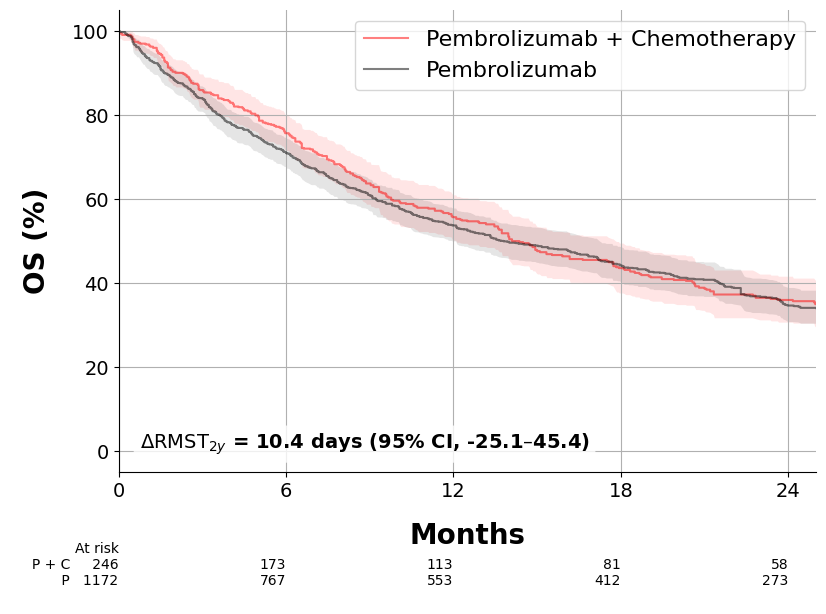

In [27]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# pembro + chemo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Pembrolizumab + Chemotherapy')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# pembro estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='Pembrolizumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 25, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 25 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST difference at 2 years
rmst_diff, rmst_lower, rmst_upper = results['difference']['rmst'][730]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{2y}$ = '
    f'{rmst_diff:.1f} days '
    f'(95% CI, {rmst_lower:.1f}–{rmst_upper:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['P + C', 'P'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

plt.savefig('../outputs/os_pembrochemo_pembro.pdf', format='pdf', bbox_inches='tight')